# RESFINDER ANALYSIS OF S. AUREUS STRAINS

In [119]:
#install.packages("readr")
.libPaths(c("~/R/x86_64-pc-linux-gnu-library/4.1", .libPaths()))


In [120]:
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(tibble)
library(purrr)
library(ggrepel)
library(pheatmap)
library(tidyr)

## OUR DATA - TANZANIA

#### 1. METADATA

In [121]:
# metadata check

metadata <- read_tsv("../../results_for_analysis/metadata/s_aureus_metadata.tsv", show_col_types = FALSE) |> 
    rename(
        sample = `Sequence file name`,
        date        = `Date of isolation`,
        sample_type = `Sample type`,
        host        = `Sample source`,
        region      = Region,
        animal_contact = `Human Contact with animals`,
        species     = Species,
        ST_meta     = ST
    )

# metadata overview

count(metadata, host)
count(metadata, region)
count(metadata, host, region) |>
    pivot_wider(names_from = region, values_from = n, values_fill = 0)

count(metadata, ST_meta, sort = TRUE)
count(metadata, sample_type, host)


metadata |>
     filter(host == "Human") |>
     count(animal_contact)




host,n
<chr>,<int>
Cow,43
Human,19


region,n
<chr>,<int>
Bagamoyo,26
D’Salaam,12
Morogoro,14
Tanga,10


host,Bagamoyo,Morogoro,Tanga,D’Salaam
<chr>,<int>,<int>,<int>,<int>
Cow,21,13,9,0
Human,5,1,1,12


ST_meta,n
<chr>,<int>
ST7846,12
ST152,11
ST97,9
ST5477,7
ST121,4
ST7841,4
ST7840,3
Unkown,3
ST7845,2


sample_type,host,n
<chr>,<chr>,<int>
Milk,Cow,43
Nasal swab,Human,19


animal_contact,n
<chr>,<int>
No,12
Yes,7


#### 2. QC PASSED ASSEMBLIES

In [122]:
passed_samples <- read_lines("../../results_for_analysis/metadata/sample_list_QC_passed.txt")

#### 3. KMERFINDER - quick species check

Rows: 62 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (6): Sample, # Sequence ID, Accession Number, Description, Taxonomy, Sp...
dbl (14): Num, Score, Expected, Template_length, Query_Coverage, Template_Co...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Sample"                "# Sequence ID"         "Num"                  
 [4] "Score"                 "Expected"              "Template_length"      
 [7] "Query_Coverage"        "Template_Coverage"     "Depth"                
[10] "tot_query_Coverage"    "tot_template_Coverage" "tot_depth"            
[13] "q_value"               "p_value"               "Accession Number"     
[16] "Description"           "TAXID"                 "Taxonomy"             
[19] "TAXID Species"         "Species"

Total isolates: 53 
Passed QC:      51 
Flagged:        2 

# A tibble: 2 × 4
  sample        query_cov template_cov depth
  <chr>             <dbl>        <dbl> <dbl>
1 R0051_BC00101      54.7         95.7  24.2
2 Q0003_BC00406      35.9         83.3  88.5


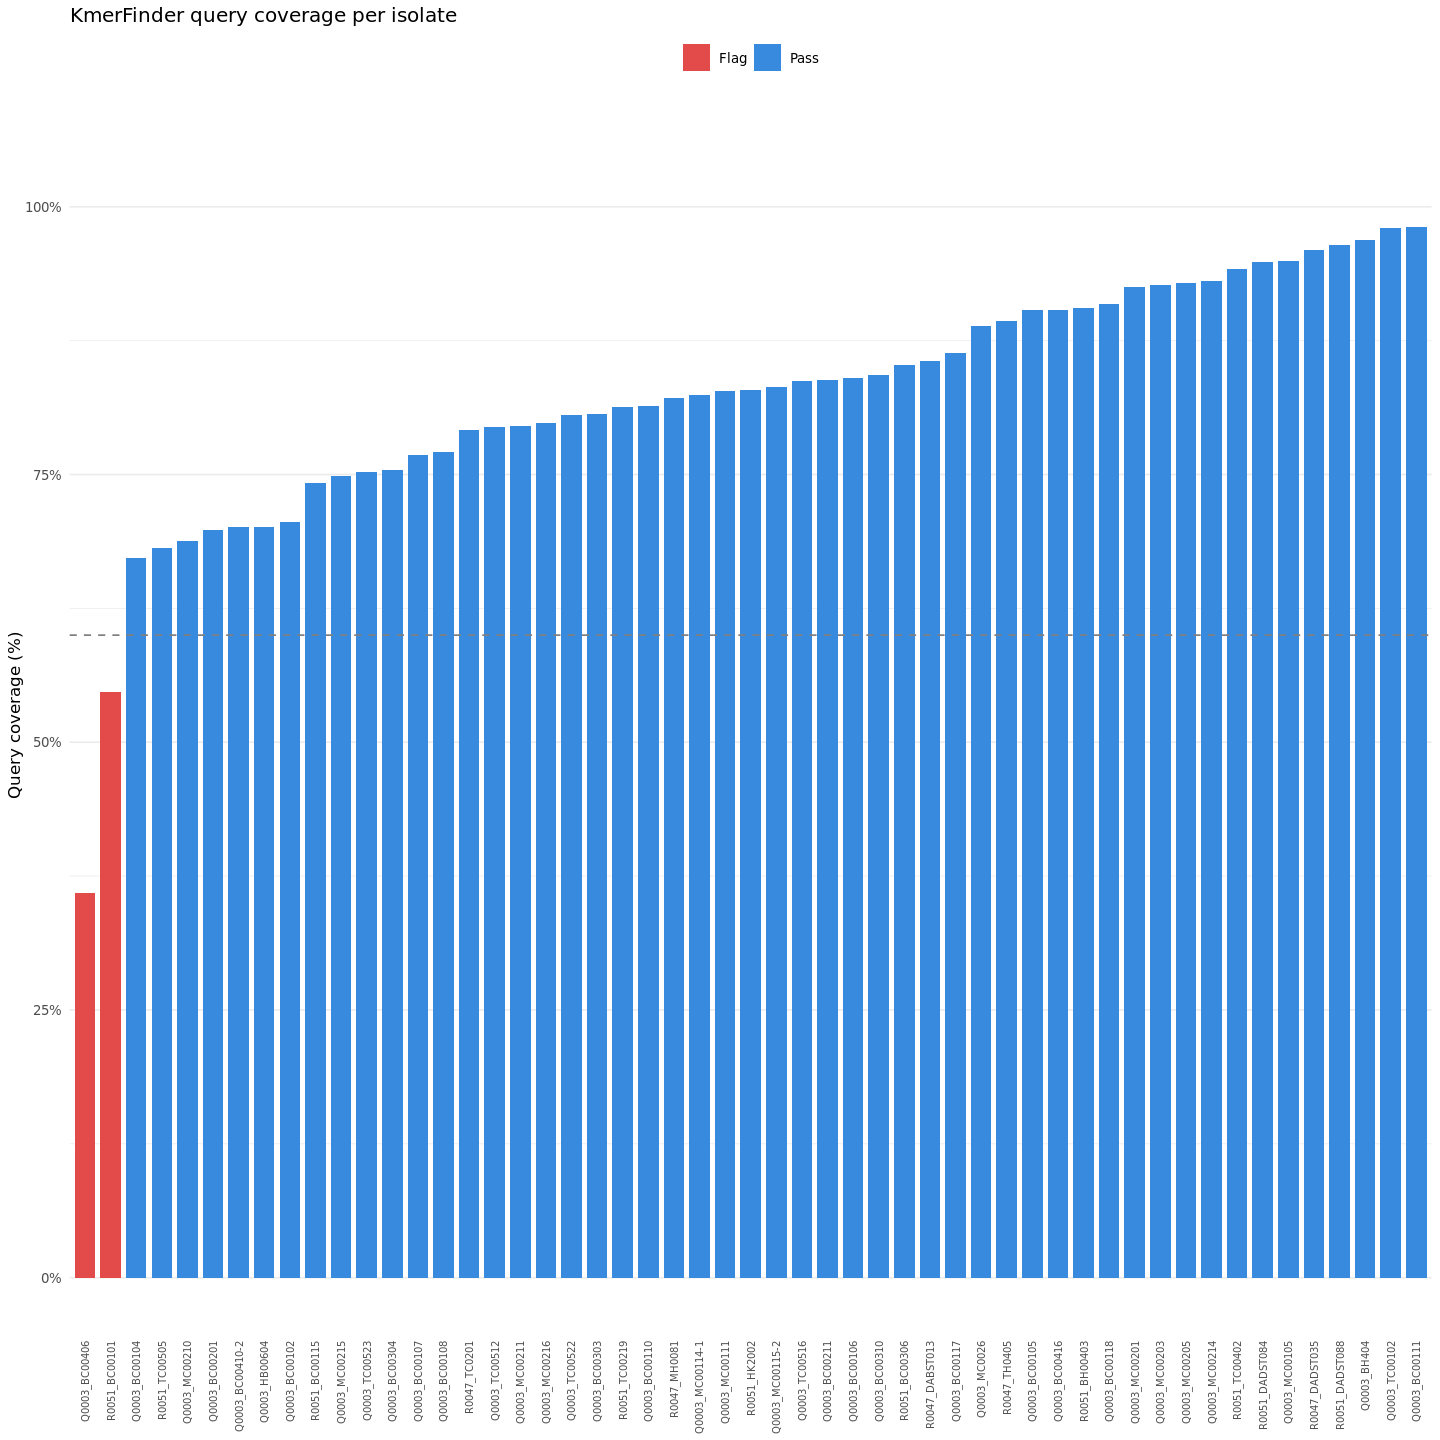

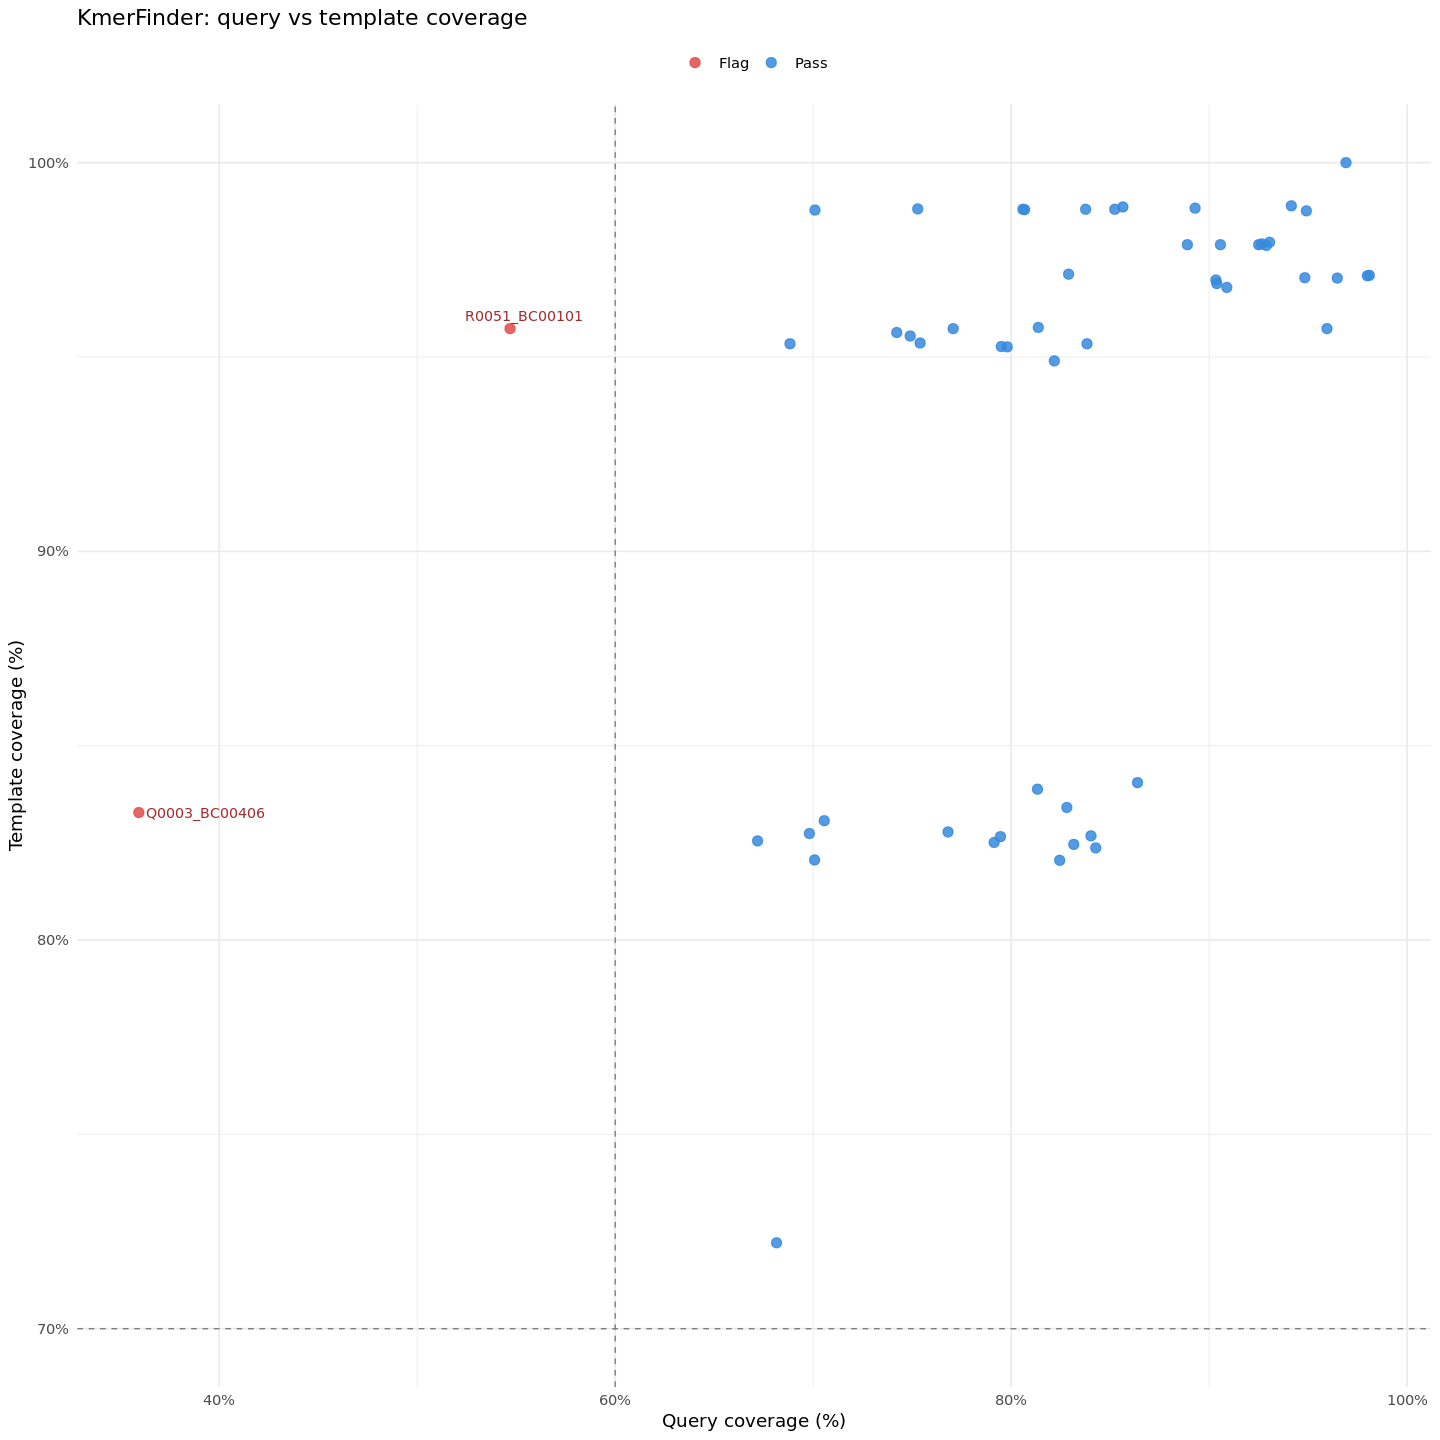

In [123]:
species_df <- read_tsv("../../results_for_analysis/kmerfinder/kmerfinder_for_trimmed_reads/kmerfinder_summary_1st_hit.txt")

# kmer - rapid species confirmation
colnames(species_df)
#species_df |> filter(Species != "Staphylococcus aureus")

species_df <- species_df |>
    filter(Sample %in% passed_samples)


# QC thresholds
QC_QUERY_COV  <- 60   # minimum query coverage %
QC_TEMPL_COV  <- 70   # minimum template coverage %

species_df <- species_df |>
  rename(
    sample          = Sample,
    query_cov       = Query_Coverage,
    template_cov    = Template_Coverage,
    depth           = Depth,
    description     = Description
  ) |>
  mutate(
    qc_pass = query_cov >= QC_QUERY_COV & template_cov >= QC_TEMPL_COV,
    label   = if_else(qc_pass, "Pass", "Flag")
  )

# summary
cat("Total isolates:", nrow(species_df), "\n")
cat("Passed QC:     ", sum(species_df$qc_pass), "\n")
cat("Flagged:       ", sum(!species_df$qc_pass), "\n\n")
print(species_df |> filter(!qc_pass) |> select(sample, query_cov, template_cov, depth))

# plot 1:
p1 <- species_df |>
  arrange(query_cov) |>
  mutate(sample = factor(sample, levels = sample)) |>
  ggplot(aes(x = sample, y = query_cov, fill = label)) +
  geom_col(width = 0.8) +
  geom_hline(yintercept = QC_QUERY_COV, linetype = "dashed", colour = "grey50", linewidth = 0.5) +
  scale_fill_manual(values = c("Pass" = "#378ADD", "Flag" = "#E24B4A")) +
  scale_y_continuous(limits = c(0, 105), labels = function(x) paste0(x, "%")) +
  labs(x = NULL, y = "Query coverage (%)",
       title = "KmerFinder query coverage per isolate",
       fill = NULL) +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
        legend.position = "top",
        panel.grid.major.x = element_blank())



# plot 2
p2 <- species_df |>
  ggplot(aes(x = query_cov, y = template_cov, colour = label, label = sample)) +
  geom_point(size = 2.5, alpha = 0.85) +
  geom_vline(xintercept = QC_QUERY_COV, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  geom_hline(yintercept = QC_TEMPL_COV, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  ggrepel::geom_text_repel(data = filter(species_df, !qc_pass),
                            size = 3, colour = "#A32D2D", max.overlaps = 10) +
  scale_colour_manual(values = c("Pass" = "#378ADD", "Flag" = "#E24B4A")) +
  scale_x_continuous(labels = function(x) paste0(x, "%")) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  labs(x = "Query coverage (%)", y = "Template coverage (%)",
       title = "KmerFinder: query vs template coverage",
       colour = NULL) +
  theme_minimal(base_size = 11) +
  theme(legend.position = "top")



p1
p2

#### 4. MLST RESULTS

In [124]:
# mlst typing 

mlst_df <- read_tsv("../../results_for_analysis/mlst/mlst_summary.txt", col_names = FALSE, show_col_types = FALSE)
colnames(mlst_df) <- c("sample", "species", "ST", "gene1", "gene2", "gene3", "gene4", "gene5", "gene6", "gene7")

mlst_df <- mlst_df |>
    mutate(sample = sample |>
        str_remove("^/home/projects/course_23262/group/group1/23262_infectious_disease_project/data/assemblies_QC_passed/") %>%
        str_remove("\\.fasta$")) |>
        filter(sample %in% passed_samples)

mlst_df |> count(ST, sort=TRUE)

ST,n
<chr>,<int>
7846,12
97,9
152,8
5477,6
7841,4
7840,3
121,2
7845,2
-,1


In [125]:
# compare metadata and mlst results

meta_vs_mlst <- metadata |>
  left_join(mlst_df |> select(sample, ST_mlst = ST), by = "sample") |>
  mutate(
    # normalise metadata ST: strip "ST" prefix, fix typos
    ST_meta_clean = str_remove(ST_meta, "^ST") |> str_trim(),
    ST_meta_clean = case_when(
      ST_meta_clean == "Unknown" ~ NA_character_,
      ST_meta_clean == "Unkown"  ~ NA_character_,   # typo in metadata
      TRUE                       ~ ST_meta_clean
    ),
    ST_mlst_clean = as.character(ST_mlst),
    # agreement check
    ST_match = case_when(
      is.na(ST_meta_clean)  ~ "meta_unknown",
      is.na(ST_mlst_clean)  ~ "mlst_missing",
      ST_mlst_clean == "-" ~ "mlst_missing",
      is.na(ST_meta_clean) & is.na(ST_mlst_clean) ~ "both_missing",
      ST_meta_clean == ST_mlst_clean ~ "match",
      TRUE                           ~ "mismatch"
    )
  )

#inspect
count(meta_vs_mlst, ST_match)

meta_vs_mlst |>
  filter(ST_match == "mismatch") |>
  select(sample, ST_meta, ST_mlst, host, region)

# remove samples that didnt pass qc at assembly
# because i only ran resfinder with qc passed assemblies_QC_passed
meta_vs_mlst <- meta_vs_mlst |>
  filter(sample %in% passed_samples)

print("Inspection after filtering:")
#inspect again after filtering
count(meta_vs_mlst, ST_match)

meta_vs_mlst |>
  filter(ST_match == "mismatch") |>
  select(sample, ST_meta, ST_mlst, host, region)

# WELL THIS IS GOOD NEWS

ST_match,n
<chr>,<int>
match,52
meta_unknown,4
mlst_missing,6


sample,ST_meta,ST_mlst,host,region
<chr>,<chr>,<chr>,<chr>,<chr>


[1] "Inspection after filtering:"


ST_match,n
<chr>,<int>
match,52
mlst_missing,1


sample,ST_meta,ST_mlst,host,region
<chr>,<chr>,<chr>,<chr>,<chr>


Here I checked the agreement between metadata and our mlst results.
Most are okay, and one is missing in mlst.
Good news!! The one missing in MLST can be either taken from metadata or left empty. Doesn't really matter I think
 

In [126]:
colnames(meta_vs_mlst)

[1] "sample"             "date"               "sample_type"       
 [4] "host"               "region"             "animal_contact"    
 [7] "species"            "ST_meta"            "Sequencing machine"
[10] "ST_mlst"            "ST_meta_clean"      "ST_mlst_clean"     
[13] "ST_match"

In [127]:
# resolve with mlst priority
final_strain_data <- meta_vs_mlst |>
    mutate(ST_final = case_when(
      ST_mlst_clean != "-"  ~ ST_mlst_clean,   # trust MLST first
      !is.na(ST_meta_clean)  ~ ST_meta_clean
     )) |> 
     select(-c(ST_meta, ST_meta_clean, ST_mlst_clean, ST_match, `Sequencing machine`))

count(final_strain_data, ST_final, sort = TRUE)


ST_final,n
<chr>,<int>
7846,12
97,9
152,8
5477,7
7841,4
7840,3
121,2
7845,2
22,1


We end up with 8 ST152 !!

#### 5. RESFINDER 

In [128]:
#load data
pheno <- read_tsv("../../results_for_analysis/resfinder/our_data/all_pheno_table.tsv", show_col_types = FALSE)
resfinder_df <- read_tsv("../../results_for_analysis/resfinder/our_data/all_resfinder_tab.tsv", show_col_types = FALSE)

colnames(resfinder_df)


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


[1] "Sample"                       "Resistance gene"             
 [3] "Identity"                     "Alignment Length/Gene Length"
 [5] "Coverage"                     "Position in reference"       
 [7] "Contig"                       "Position in contig"          
 [9] "Phenotype"                    "Accession no."

In [129]:
resfinder_filtered <- resfinder_df |> 
    select(c(Sample, `Resistance gene`, Phenotype, Identity, Coverage)) |>
    rename(
        sample = Sample,
        gene = `Resistance gene`,
        phenotype = Phenotype,
        coverage = Coverage,
        identity = Identity
    ) |>
    # remove duplicated genes per sample
    distinct()

# add back samples with no resistance genes
resfinder_filtered <- tibble(sample = passed_samples) |>
    left_join(resfinder_filtered, by = "sample")


In [130]:
# presence / absence matrix for the gene heatmap

pa_mat <- resfinder_filtered |>
    filter(!is.na(gene)) |>
    mutate(present = 1L) |>
    pivot_wider(id_cols = sample, names_from = gene,
                values_from = present, values_fill = 0L)

# add back samples with no genes
missing_samples <- setdiff(passed_samples, pa_mat$sample)

pa_mat <- pa_mat |>
    bind_rows(tibble(sample = missing_samples)) |>
    mutate(across(where(is.numeric), ~replace_na(.x, 0))) |>
    column_to_rownames("sample") |>
    as.matrix()



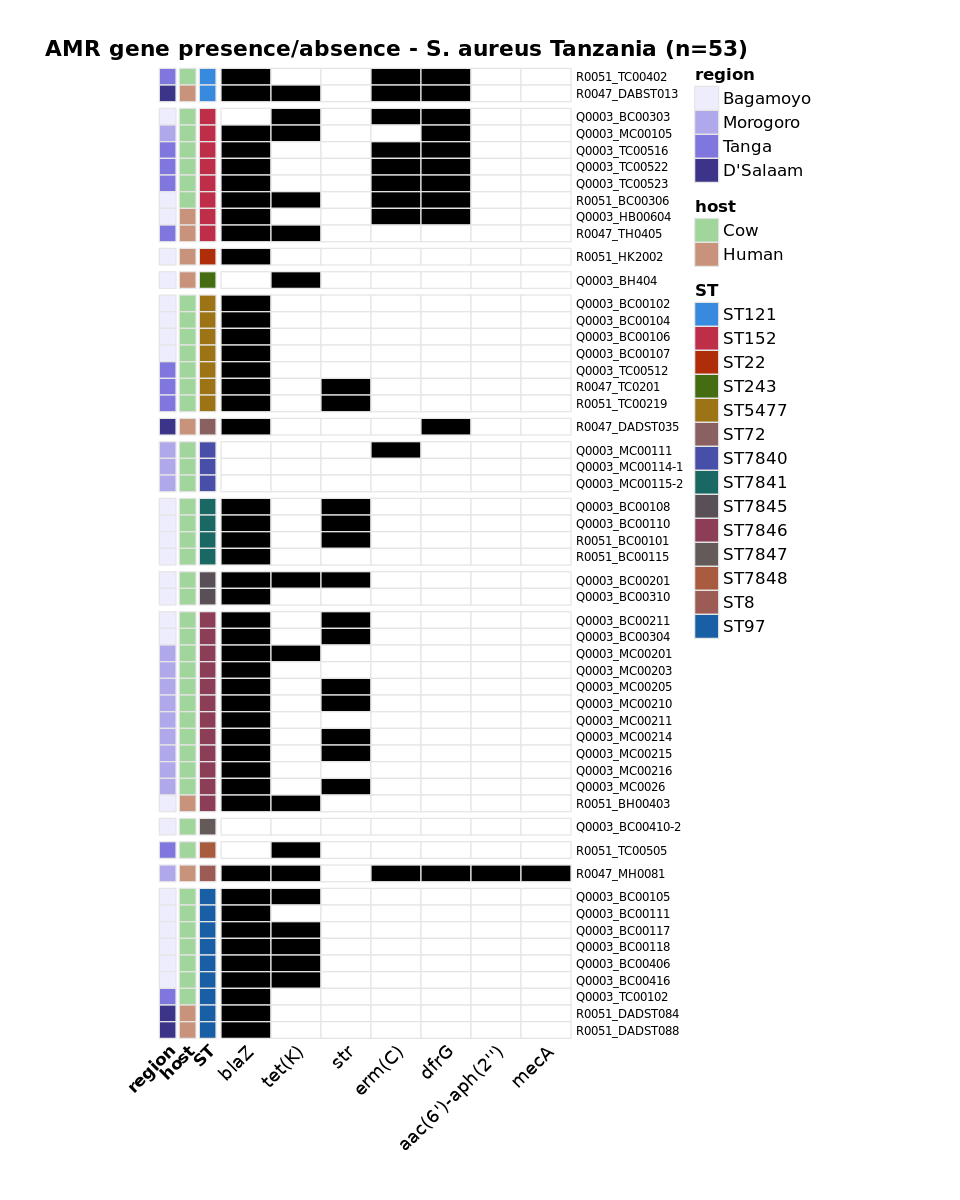

In [131]:
# build annotation

annot_row <- final_strain_data |>
    mutate(
      ST = paste0("ST", ST_final),
      region = iconv(region, from = "UTF-8", to = "ASCII//TRANSLIT") #idk encoding is a bitch
    ) |>
    select(sample, ST, host, region) |>
    arrange(ST, host) |>
    column_to_rownames("sample")



# match matrix row order to annotation
pa_mat <- pa_mat[rownames(annot_row), , drop=FALSE]

# create gaps between ST groups
gap_pos <- annot_row |>
  mutate(row_n = row_number()) |>
  group_by(ST) |>
  summarise(last = max(row_n), .groups = "drop") |>
  arrange(last) |>
  pull(last) |>
  head(-1)


# colors for heatmap

st_levels <- unique(annot_row$ST) |> sort()
st_cols <- setNames(
  colorRampPalette(c("#378ADD","#fa0606","#3B6D11","#BA7517",
                     "#534AB7","#0F6E56","#993556","#5F5E5A",
                     "#D85A30","#185FA5"))(length(st_levels)),
  st_levels
)

ann_colors <- list(
  ST = st_cols,
  host = c(
    "Cow" = "#a0d69c",    # choose any hex
    "Human" = "#c9937b"
  ),
  region = c(
    "Bagamoyo" = "#EEEDFE",
    "Morogoro" = "#AFA9EC",
    "Tanga" = "#7F77DD",
    "D\'Salaam" = "#3C3489"
  )
)
# heatmap. finally omg

options(repr.plot.width = 8, repr.plot.height = 10)


pheatmap(
  pa_mat,
  annotation_row    = annot_row,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos,
  color             = c("white", "black"),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = FALSE,
  main              = "AMR gene presence/absence - S. aureus Tanzania (n=53)",
  #          = "results/resfinder_heatmap.pdf",
  width             = 14,
  height            = 18
)

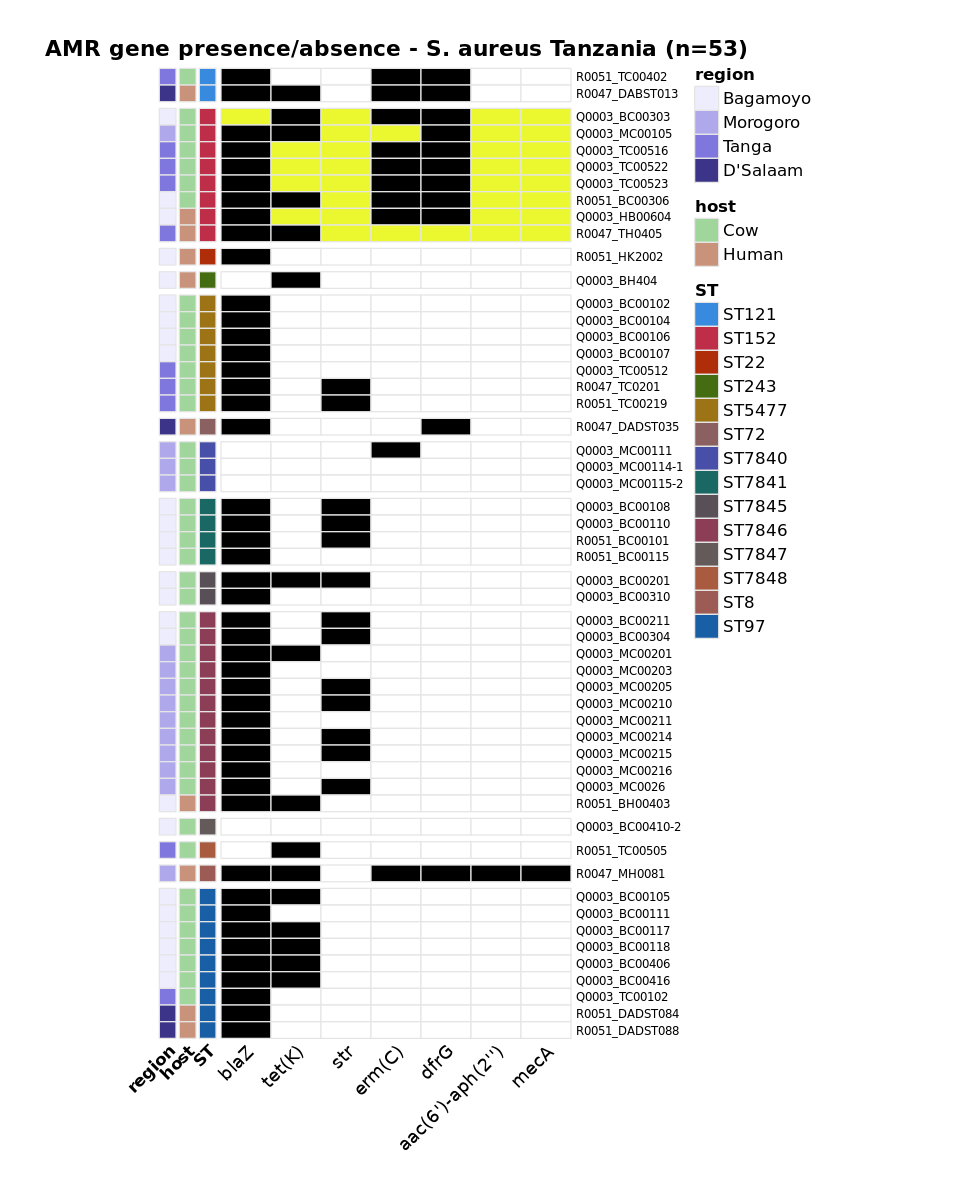

In [132]:

# make ST152 emoty cells light yellow
pa_plot <- pa_mat
st152_rows <- rownames(annot_row)[annot_row$ST == "ST152"]

tmp <- pa_plot[st152_rows, , drop = FALSE]
tmp[tmp == 0] <- -1
pa_plot[st152_rows, ] <- tmp

pheatmap(
  pa_plot,
  annotation_row    = annot_row,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos,
  color             = c("#ebf830", "white", "black"),  # ST152-0, other-0, 1
  breaks            = c(-1.5, -0.5, 0.5, 1.5),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = FALSE,
  main              = "AMR gene presence/absence - S. aureus Tanzania (n=53)"
)


We can already see this strain is more resistant!!!!

## AUGMENTED DATA FROM MLSTPUB

#### 

In [133]:
resfinder_aug <- read_tsv("../../results_for_analysis/resfinder/aug_data/all_resfinder_tab.tsv", show_col_types = FALSE)
passed_samples_aug <- read_tsv("../../results_for_analysis/metadata/sample_list_augm_postQC.txt", col_names = FALSE) 

head(resfinder_aug)
head(passed_samples_aug)

Rows: 112 Columns: 1
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Sample,Resistance gene,Identity,Alignment Length/Gene Length,Coverage,Position in reference,Contig,Position in contig,Phenotype,Accession no.
<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
ST121_id24328_ERR505363.fasta,blaZ,100,846/846,100.00000,1..846,ERR505363_A130980_NODE_27_COV_59.977810,6658..7503,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",AP004832
ST121_id24328_ERR505363.fasta,dfrG,100,498/498,100.00000,1..498,ERR505363_A130980_NODE_29_COV_18.282499,53332..53829,Trimethoprim,AB205645
ST121_id24971_ERR505373.fasta,blaZ,100,888/888,100.00000,1..888,ERR505373_A131753_NODE_4_COV_24.781187,9189..10076,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",CP003979
ST121_id24971_ERR505373.fasta,erm(C),100,735/735,100.00000,1..735,ERR505373_A131753_NODE_20_COV_278.088959,396..1130,"Erythromycin, Lincomycin, Clindamycin, Quinupristin, Pristinamycin IA, Virginiamycin S",M13761
ST121_id24971_ERR505373.fasta,tet(K),100,1112/1380,80.57971,269..1380,ERR505373_A131753_NODE_111_COV_259.767303,1..1112,"Doxycycline, Tetracycline",U38656
ST121_id24971_ERR505373.fasta,tet(K),100,352/1380,25.50725,1..352,ERR505373_A131753_NODE_111_COV_259.767303,4172..4523,"Doxycycline, Tetracycline",U38656


X1
<chr>
ST121_id24328_ERR505363
ST121_id24971_ERR505373
ST121_id24973_ERR505392
ST121_id30867_ERR490597
ST121_id30879_ERR490626
ST121_id31033_ERR490607


In [134]:
resfinder_aug <- resfinder_aug |> 
    select(c(Sample, `Resistance gene`, Phenotype, Identity, Coverage)) |>
    rename(
        sample = Sample,
        gene = `Resistance gene`,
        phenotype = Phenotype,
        coverage = Coverage,
        identity = Identity
    ) |>
    mutate(sample = str_remove(sample, "\\.fasta$")) |>
    # filter to only consider qc passed samples
    filter(sample %in% passed_samples_aug$X1) |>
    # remove duplicated genes per sample
    distinct()



In [135]:
# get missing samples info
missing_samples <- setdiff(passed_samples_aug$X1, resfinder_aug$sample)

# additional filtering just in case
resfinder_aug <- resfinder_aug |>
  filter(is.na(identity) | identity >= 90) |>
  filter(is.na(coverage) | coverage >= 60) |>
  distinct(sample, gene, .keep_all = TRUE)

head(resfinder_aug)



sample,gene,phenotype,identity,coverage
<chr>,<chr>,<chr>,<dbl>,<dbl>
ST121_id24328_ERR505363,blaZ,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",100,100.00000
ST121_id24328_ERR505363,dfrG,Trimethoprim,100,100.00000
ST121_id24971_ERR505373,blaZ,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",100,100.00000
ST121_id24971_ERR505373,erm(C),"Erythromycin, Lincomycin, Clindamycin, Quinupristin, Pristinamycin IA, Virginiamycin S",100,100.00000
ST121_id24971_ERR505373,tet(K),"Doxycycline, Tetracycline",100,80.57971
ST121_id24971_ERR505373,dfrG,Trimethoprim,100,100.00000


In [136]:
missing_samples

[1] "ST152_id46095_ECJ"      "ST22_id37156_SA82"      "ST5477_id37103_wp2017" 
[4] "ST5477_id37107_wp2017"  "ST7847_id38591_FF22"    "ST8_id37152_SA20"      
[7] "ST97_id21212_ERR227490" "ST97_id37151_SA18"

In [137]:
# gene p/a matrix
pa_mat_aug <- resfinder_aug |>
    filter(!is.na(gene)) |>
    mutate(present = 1L) |>
    pivot_wider(id_cols = sample, names_from = gene,
                values_from = present, values_fill = 0L)

pa_mat_aug <- pa_mat_aug |>
    # add back missing samples
    bind_rows(tibble(sample = missing_samples)) |>
    mutate(across(where(is.numeric), ~replace_na(.x, 0))) |>
    column_to_rownames("sample") |>
    as.matrix()



In [138]:
# matrix to data frame and add sample column
pa_df <- as.data.frame(pa_mat_aug)
pa_df$sample <- rownames(pa_mat_aug)

# strain from sample name (everything matching ST* before first _)
pa_df <- pa_df |>
  mutate(strain = str_extract(sample, "^ST[0-9]+"))

# count genomes per strain BEFORE averaging
strain_counts <- pa_df |>
  count(strain, name = "n_genomes")

# group by strain and calculate mean for each gene column
pa_strain_avg <- pa_df |>
  group_by(strain) |>
  summarise(across(where(is.numeric), mean, na.rm = TRUE)) |>
  left_join(strain_counts, by = "strain") |>
  mutate(strain_label = paste0(strain, " (n=", n_genomes, ")")) |>
  select(-n_genomes) |>
  column_to_rownames("strain_label") |>
  as.matrix()


In [139]:
rownames(pa_strain_avg)

[1] "ST121 (n=10)" "ST152 (n=54)" "ST22 (n=5)"   "ST5477 (n=5)" "ST72 (n=5)"  
 [6] "ST7840 (n=1)" "ST7841 (n=1)" "ST7845 (n=1)" "ST7846 (n=1)" "ST7847 (n=1)"
[11] "ST7848 (n=1)" "ST8 (n=18)"   "ST97 (n=9)"

In [158]:
# annot for strain avg
strain_annot <- data.frame(
  ST     = str_extract(rownames(pa_strain_avg), "^ST[0-9]+"),
  host   = "MLSTPUB_avg",
  region = NA,
  row.names = rownames(pa_strain_avg)
)
annot_row_combined <- rbind(annot_row, strain_annot)

# all unique gene columns from both matrices
all_genes <- union(colnames(pa_mat), colnames(pa_strain_avg))

#  columns to pa_mat (fill with 0)
for (gene in setdiff(all_genes, colnames(pa_mat))) {
  pa_mat <- cbind(pa_mat, setNames(data.frame(rep(0, nrow(pa_mat))), gene))
}

# columns to pa_strain_avg (fill with 0)
for (gene in setdiff(all_genes, colnames(pa_strain_avg))) {
  pa_strain_avg <- cbind(pa_strain_avg, setNames(data.frame(rep(0, nrow(pa_strain_avg))), gene))
}

# Reorder columns to match
pa_mat <- pa_mat[, all_genes, drop=FALSE]
pa_strain_avg <- pa_strain_avg[, all_genes, drop=FALSE]

# Combine
pa_combined <- rbind(pa_mat, pa_strain_avg) |> select(-strain)



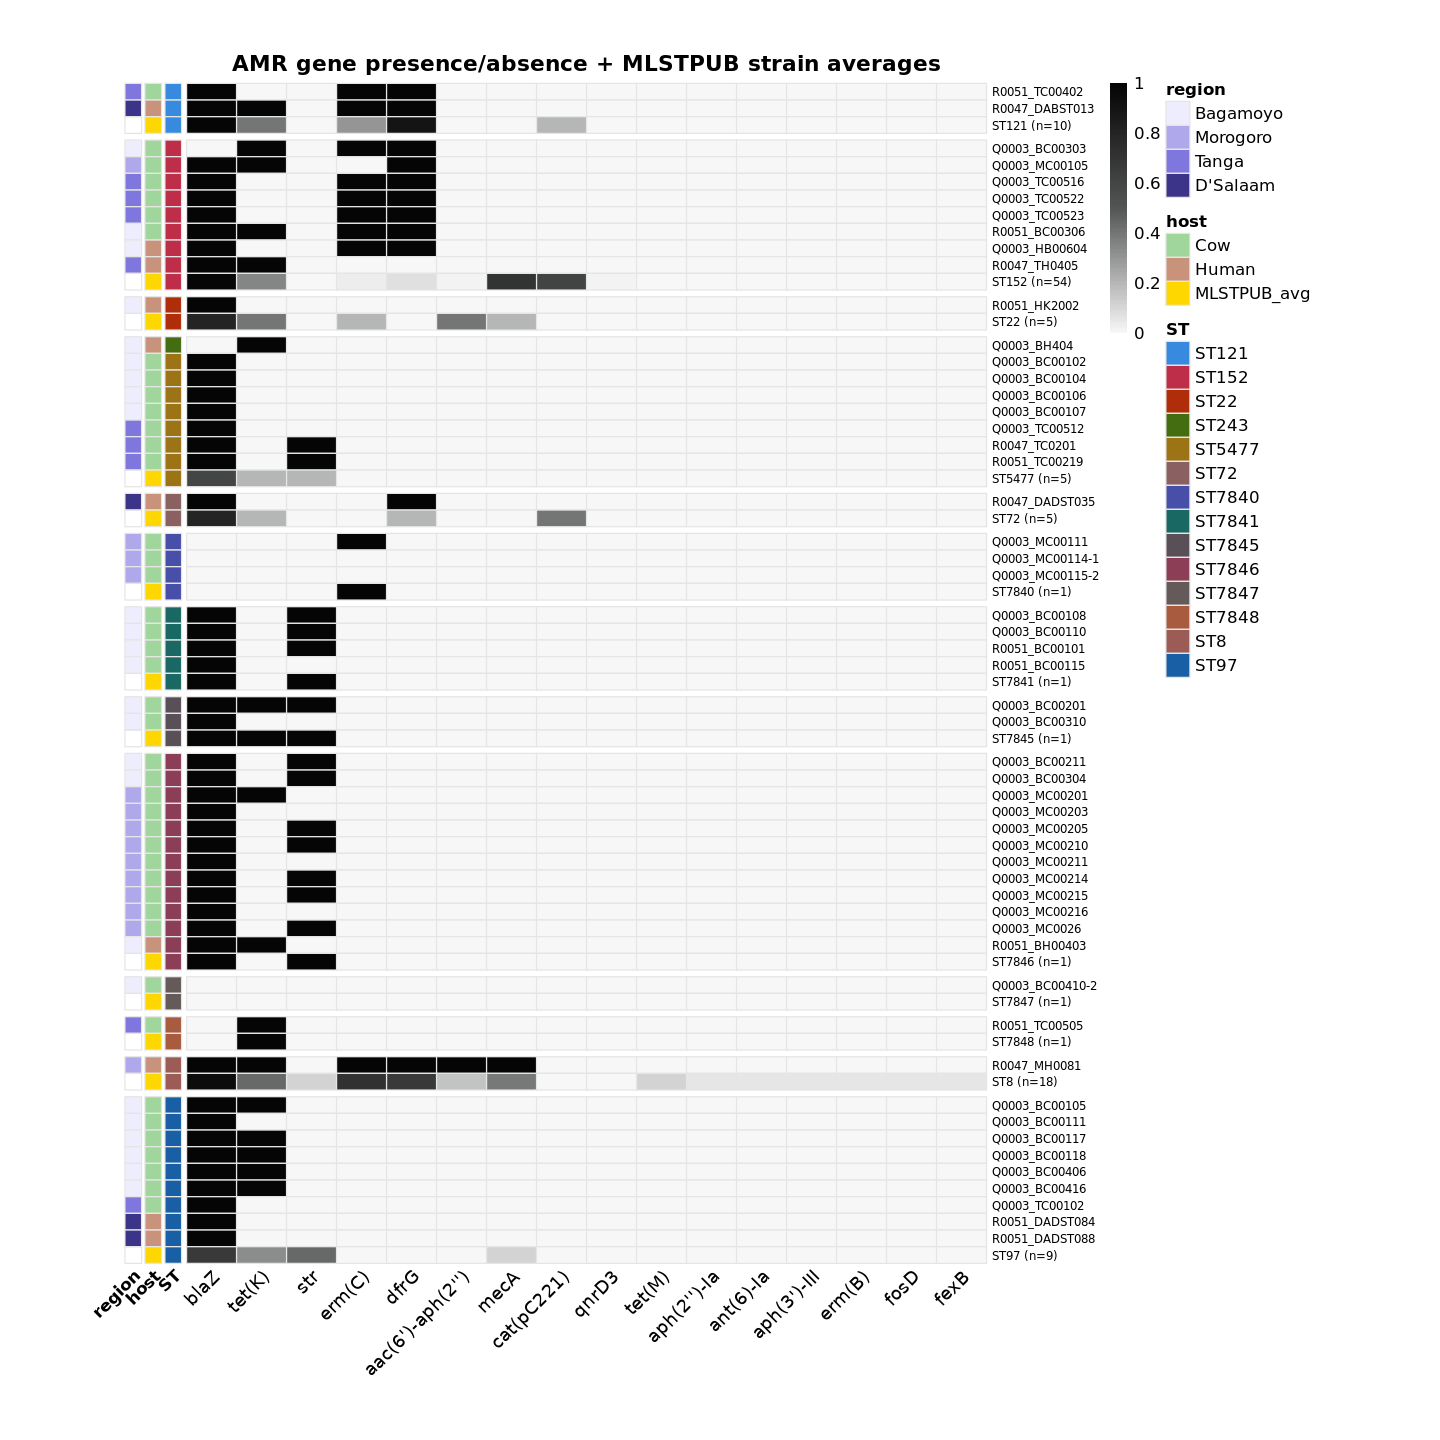

In [159]:
options(repr.plot.width = 12, repr.plot.height = 12)

# Update ST levels and colors to include MLSTPUB_avg rows
st_levels_combined <- unique(annot_row_combined$ST) |> sort()
st_cols_combined <- setNames(
  colorRampPalette(c("#378ADD","#fa0606","#3B6D11","#BA7517",
                     "#534AB7","#0F6E56","#993556","#5F5E5A",
                     "#D85A30","#185FA5"))(length(st_levels_combined)),
  st_levels_combined
)

ann_colors_combined <- ann_colors
ann_colors_combined$ST <- st_cols_combined
ann_colors_combined$host <- c(ann_colors$host, "MLSTPUB_avg" = "#FFD700")

# Get sample and average row names
sample_rows <- rownames(pa_mat)
avg_rows    <- rownames(pa_strain_avg)  # now named like "ST97 (n=42)"

# Extract ST for each sample
sample_ST <- annot_row[sample_rows, "ST"]

# avg_ST: strip the "(n=...)" suffix to match original ST labels
avg_ST_key <- setNames(
  str_extract(avg_rows, "^ST[0-9]+"),
  avg_rows
)

# Build new order: samples for each ST, then its avg row
new_order <- c()
for (st in unique(sample_ST)) {
  these_samples <- sample_rows[sample_ST == st]
  new_order <- c(new_order, these_samples)
  matching_avg <- names(avg_ST_key)[avg_ST_key == st]
  if (length(matching_avg) > 0) {
    new_order <- c(new_order, matching_avg)
  }
}

# Reorder
pa_combined <- pa_combined[new_order, , drop=FALSE]
pa_combined[] <- lapply(pa_combined, as.numeric)
pa_combined <- as.matrix(pa_combined)

annot_row_combined <- annot_row_combined[new_order, , drop=FALSE]

# Gaps AFTER each avg row (= end of each strain block)
gap_pos_combined <- which(annot_row_combined$host == "MLSTPUB_avg")
gap_pos_combined <- gap_pos_combined[gap_pos_combined < nrow(annot_row_combined)]

# Plot
pheatmap(
  pa_combined,
  annotation_row    = annot_row_combined,
  annotation_colors = ann_colors_combined,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos_combined,
  color             = colorRampPalette(c("#F7F7F7", "#545555", "#050505"))(101),
  breaks            = seq(0, 1, length.out = 102),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = TRUE,
  main              = "AMR gene presence/absence + MLSTPUB strain averages",
  width             = 14,
  height            = 18
)

In [ ]:
# ── 1. Gene universe: only genes found in our Tanzania data ──────────────────
our_genes <- colnames(pa_mat)

# ── 2. Tanzania averages by ST ───────────────────────────────────────────────
tz_counts <- data.frame(ST = annot_row$ST, stringsAsFactors = FALSE) |>
  count(ST, name = "n_genomes")

tz_avg <- pa_mat |>
  as.data.frame() |>
  mutate(ST = annot_row[rownames(pa_mat), "ST"]) |>
  group_by(ST) |>
  summarise(across(everything(), mean, na.rm = TRUE), .groups = "drop") |>
  left_join(tz_counts, by = "ST") |>
  mutate(label = paste0(ST, " (n=", n_genomes, ")")) |>
  select(-n_genomes) |>
  column_to_rownames("label") |>
  select(-ST) |>
  as.matrix()

# ── 3. MLSTPUB averages — same genes only ───────────────────────────────────
# Subset pa_mat_aug to our_genes (fill missing genes with 0)
aug_genes_present <- intersect(our_genes, colnames(pa_mat_aug))
aug_missing       <- setdiff(our_genes, colnames(pa_mat_aug))

pa_aug_sub <- pa_mat_aug[, aug_genes_present, drop = FALSE]
if (length(aug_missing) > 0) {
  pa_aug_sub <- cbind(pa_aug_sub,
    matrix(0, nrow = nrow(pa_aug_sub), ncol = length(aug_missing),
           dimnames = list(rownames(pa_aug_sub), aug_missing)))
}
pa_aug_sub <- pa_aug_sub[, our_genes, drop = FALSE]   # match column order

aug_df <- as.data.frame(pa_aug_sub)
aug_df$sample <- rownames(pa_aug_sub)
aug_df <- aug_df |>
  mutate(strain = str_extract(sample, "^ST[0-9]+"))

aug_counts <- aug_df |> count(strain, name = "n_genomes")

pub_avg <- aug_df |>
  group_by(strain) |>
  summarise(across(where(is.numeric), mean, na.rm = TRUE), .groups = "drop") |>
  left_join(aug_counts, by = "strain") |>
  mutate(label = paste0(strain, " (n=", n_genomes, ")")) |>
  select(-n_genomes, -strain) |>
  column_to_rownames("label") |>
  as.matrix()

# ── 4. Align rows: only STs present in both ──────────────────────────────────


tz_plot  <- tz_avg [tz_st  %in% shared_sts, , drop = FALSE]
pub_plot <- pub_avg[pub_st %in% shared_sts, , drop = FALSE]

# Sort both by ST number so rows line up
tz_plot  <- tz_avg[order(str_extract(rownames(tz_plot),  "^ST[0-9]+")), ]
pub_plot <- pub_avg[order(str_extract(rownames(pub_plot), "^ST[0-9]+")), ]

# ── 5. Shared color scale ────────────────────────────────────────────────────
heatmap_colors <- colorRampPalette(c("#F7F7F7", "#92C5DE", "#2166AC"))(101)
heatmap_breaks <- seq(0, 1, length.out = 102)

# ── 6. Plot side by side ─────────────────────────────────────────────────────
options(repr.plot.width = 20, repr.plot.height = 6)

p_tz <- pheatmap(
  tz_plot,
  cluster_rows  = FALSE,
  cluster_cols  = FALSE,
  color         = heatmap_colors,
  breaks        = heatmap_breaks,
  border_color  = "grey90",
  cellwidth     = 30,
  cellheight    = 18,
  fontsize_row  = 9,
  fontsize_col  = 10,
  angle_col     = 45,
  legend        = TRUE,
  main          = "Tanzania (our data)",
  #silent        = TRUE
)

p_pub <- pheatmap(
  pub_plot,
  cluster_rows  = FALSE,
  cluster_cols  = FALSE,
  color         = heatmap_colors,
  breaks        = heatmap_breaks,
  border_color  = "grey90",
  cellwidth     = 30,
  cellheight    = 18,
  fontsize_row  = 9,
  fontsize_col  = 10,
  angle_col     = 45,
  legend        = FALSE,   # shared legend already shown on left
  main          = "MLSTPUB (public genomes)",
  #silent        = TRUE
)

p_tz
p_pub
gridExtra::grid.arrange(p_tz$gtable, p_pub$gtable, ncol = 2)

,blaZ,tet(K),str,erm(C),dfrG,aac(6')-aph(2''),mecA,cat(pC221),qnrD3,tet(M),aph(2'')-Ia,ant(6)-Ia,aph(3')-III,erm(B),fosD,fexB
ST121 (n=10),1.0000000,0.4000000,0.0000000,0.30000000,0.90000000,0.00000000,0.0000000,0.2000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST152 (n=54),0.9814815,0.3518519,0.0000000,0.03703704,0.07407407,0.01851852,0.7037037,0.6111111,0.01851852,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST22 (n=5),0.8000000,0.4000000,0.0000000,0.20000000,0.00000000,0.40000000,0.2000000,0.0000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST5477 (n=5),0.6000000,0.2000000,0.2000000,0.00000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST72 (n=5),0.8000000,0.2000000,0.0000000,0.00000000,0.20000000,0.00000000,0.0000000,0.4000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST7840 (n=1),0.0000000,0.0000000,0.0000000,1.00000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST7841 (n=1),1.0000000,0.0000000,1.0000000,0.00000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST7845 (n=1),1.0000000,1.0000000,1.0000000,0.00000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST7846 (n=1),1.0000000,0.0000000,1.0000000,0.00000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
ST7847 (n=1),0.0000000,0.0000000,0.0000000,0.00000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000


In [164]:
library(gridExtra)



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


